# Imports

In [1]:
# Usual stuff
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Scipy
import scipy as sp
import scipy.sparse as spr

# Typing
from typing import Callable

# Hamiltonian

We can now write the Hamiltonian including AFM and SC interaction as ([View more](https://www.notion.so/8-Superconducting-Instability-2a2b911af6a78021b002f7aad6a38266?pvs=21) - the SC is treated at the mean-field level):

$$
\begin{align*}

H &= \sum_{k=0}^{\pi/2} H_k

\end{align*}
$$

Where:

- $H_k$ couples the $\pm k$ modes with the $\pm k + \pi$ modes:
    
    $$
    \begin{align*}
    
    H_{k} &= H_k^\text{(HK + SC)} + H_{k+\pi}^\text{(HK + SC)}
    \\\\
    
    &\quad - J\sum_\sigma(n_{k\sigma} n_{k+\pi \bar \sigma} + n_{-k\sigma}n_{-k+\pi \bar \sigma})
    
    \end{align*}
    $$
    
- $H_k^\text{(HK + SC)}$  couples only the $\pm k$ modes:
    
    $$
    \begin{align*}
    
    H_k^\text{(HK + SC)}  &= \xi_k(n_k + n_{-k}) + U(n_{k\uarr}n_{k\darr} + n_{-k\uarr}n_{-k \darr})
    \\\\
    
    &\quad +\Delta^*(b_k + b_{-k}) + \Delta(b_k^\dag + b_{-k}^\dag)
    
    \end{align*}
    $$
    
- $b_k$ is the pair ladder operator for a Cooper pair:
    
    $$
    \begin{align*}
    
    b_k &= c_{-k\darr}c_{k\uarr}
    
    \end{align*}
    $$
    
- $\Delta$ has to be solved self-consistently for:
    
    $$
    \begin{align*}
    
    \Delta &= -\frac{g}{L_d}\sum_k\lang b_k\rang
    
    \end{align*}
    $$

We write the Hamiltonian in block-diagonal form, noticing that the number of particles pairs and the total spin are conserved, hence we get the following ten subspaces:
- **Parity of Particle Number**: Either $0$ or $1$.
- **Total Spin**: It is in the set $\pm4, \pm3, \pm2, \pm1, 0$.

## Helper Functions

In [2]:
def bissect(func: Callable, a: float, b: float, eps: float = 1e-6, maxI: int = 200, mult: bool = False) -> float:
    """
        Solves the equation `func(x) = 0` using the bissection method in [a, b].

        The function stops when the error is smaller then `eps` or the number of iterations exceeds `maxI`.

        The error is additive by default, but can be made multiplicative by setting `mult` = True

        ### Return
        x: The value of x that solves the equation.
    """

    # Evaluate on the edges
    fa, fb = func(a), func(b)

    # Check if there is a zero on the edges
    if abs(fa) <= 1e-16:
        return a
    elif abs(fb) <= 1e-16:
        return b

    # Main Loop
    i = 0
    error = (b-a)/2

    # For multiplicative error make sure to do at least one iteration
    if mult:
        error = eps + 1

    while abs(error) > eps:

        # Find the midpoint and evaluate the function there
        c = (a+b)/2
        fc = func(c)

        # Check if the zero is exactly on the midpoint
        if abs(fc) <= 1e-16:
            return c

        # Sign change happens in [a, c]
        elif fa * fc < 0:
            b = c
            fb = fc
        
        # Sign change happens in [c, b]
        elif fc * fb < 0:
            a = c
            fa = fc
        
        # No sign change
        else:
            raise ValueError(f"O sinal de f é o mesmo em a = {a} e em b = {b} (f(a) = {fa}, f(b) = {fb}) - iteração {i}).")

        # Compute the error
        error = (b - a)/2

        # If the error is multiplicative, compare the error with the midpoint value
        if mult:
            error /= (a+b)/2

        # Maximum number of iterations
        i += 1
        if i > maxI:
            raise ValueError(f"Não foi possível encontrar a raíz da função com a precisão desejada em menos de maxI = {maxI} iterações!")
        
    return (a+b)/2

In [3]:
def eps(kk: np.ndarray) -> np.ndarray:
    """
        Compute the dispersion relation for a given set of vectors `kk`.
    """
    return -2 * np.sum(np.cos(kk), axis = 0)


def fock(decimal: int, modes: int = 8) -> list[int]:
    return [(decimal >> n) % 2 for n in range(modes)][::-1]


# Sample code to convert from state to full fock space
# The four least significant bits (LSB) corresponds to k and the four MSBs corresponds to k+pi
state = 20
n_pk_ppi_u_i, n_pk_ppi_d_i, n_mk_ppi_u_i, n_mk_ppi_d_i, n_pk_npi_u_i, n_pk_npi_d_i, n_mk_npi_u_i, n_mk_npi_d_i = fock(state, 8)

We are using the basis:
$$
\begin{align*}
\ket{n_{k+\pi\uarr}, n_{k+\pi\darr}, n_{-k+\pi\uarr}, n_{-k+\pi\darr}, n_{k\uarr}, n_{k\darr}, n_{-k\uarr}, n_{-k\darr}}
\end{align*}
$$

## Subspaces

In [4]:
# CONSTANTS
MODES = 8
DIM = 2**MODES


# SUBSPACES
class Subspace:

    # Get properties and states
    # Technically we could even forget about the quantum numbers
    def __init__(self, parity: int, spin: int) -> None:
        # Quantum numbers of the subspace
        self.parity = parity
        self.spin = spin

        # States and dimension
        self.states = []
        self.dimension = 0
        self.Nk = 0

        # Lookup table
        self.lookup = dict()
    
    # Print
    def __str__(self) -> str:
        return f"Space with P = {self.parity} and S = {self.spin} contains {len(self.states)} states."

    
    # STATES
    
    # Add a state to the list
    def add_state(self, st: int) -> None:
        self.states += [st]

    # Build a lookup table {state: position} on the list
    def build_lookup(self) -> None:
        self.dimension = len(self.states)

        for index, st in enumerate(self.states):
            self.lookup[st] = index


    # OPERATORS

    # Create the operators
    def build_operators(self) -> tuple[np.ndarray, np.ndarray]:

        # Make sure we have a lookup table
        if len(self.lookup) == 0: self.build_lookup()

        # Operators (t for total, meaning both options)
        self.nk_tk_tpi_t = np.zeros((self.dimension, self.dimension), dtype=np.float64)

        self.nk_tk_tpi_d = np.zeros((self.dimension, self.dimension), dtype=np.float64)
        self.nk_tk_tpi_u = np.zeros((self.dimension, self.dimension), dtype=np.float64)

        self.nk_tk_npi_t = np.zeros((self.dimension, self.dimension), dtype=np.float64)
        self.nk_tk_ppi_t = np.zeros((self.dimension, self.dimension), dtype=np.float64)
        
        self.bk_tk_tpi = np.zeros((self.dimension, self.dimension), dtype=np.float64)

        self.afmk = np.zeros((self.dimension, self.dimension), dtype=np.float64)

        for st in self.states:
            # Position of the state
            ket = self.lookup[st]

            # Binary decomposition
            st_list = fock(st)
            n_pk_ppi_u, n_pk_ppi_d, n_mk_ppi_u, n_mk_ppi_d, n_pk_npi_u, n_pk_npi_d, n_mk_npi_u, n_mk_npi_d = st_list

            # Number of particles in the state
            self.nk_tk_tpi_t[ket, ket] = np.sum(st_list)

            # Number of particles with spin up and spin down
            self.nk_tk_tpi_u[ket, ket] = n_pk_ppi_u + n_mk_ppi_u + n_pk_npi_u + n_mk_npi_u
            self.nk_tk_tpi_d[ket, ket] = n_pk_ppi_d + n_mk_ppi_d + n_pk_npi_d + n_mk_npi_d

            # Number of particles at ±k and ±(k+pi)
            self.nk_tk_npi_t[ket, ket] = n_pk_npi_u + n_pk_npi_d + n_mk_npi_u + n_mk_npi_d
            self.nk_tk_ppi_t[ket, ket] = n_pk_ppi_u + n_pk_ppi_d + n_mk_ppi_u + n_mk_ppi_d


            # Applying bk to this state (st is the ket, we find the bra)
            # For the first and third lines, the phase is n_pk_npi_u-1 + n_pk_npi_d + n_mk_npi_u bu the first term is 0 because it is 1-1
            if n_mk_npi_d * n_pk_npi_u:
                bra_pk_npi = self.lookup[st - 8 - 1]
                self.bk_tk_tpi[bra_pk_npi, ket] += (-1)**(n_pk_npi_d + n_mk_npi_u)
            
            if n_pk_npi_d * n_mk_npi_u:
                bra_mk_npi = self.lookup[st - 4 - 2]
                self.bk_tk_tpi[bra_mk_npi, ket] += (-1)**(n_pk_npi_d)
            
            if n_pk_ppi_u * n_mk_ppi_d:
                bra_pk_ppi = self.lookup[st - 128 - 16]
                self.bk_tk_tpi[bra_pk_ppi, ket] += (-1)**(n_pk_ppi_d + n_mk_ppi_u)
            
            if n_pk_ppi_d * n_mk_ppi_u:
                bra_mk_ppi = self.lookup[st - 64 - 32]
                self.bk_tk_tpi[bra_mk_ppi, ket] += (-1)**(n_pk_ppi_d)
            
            # Staggered magnetization measurement
            if (1 - n_pk_npi_u) * n_pk_ppi_u:
                bra_pk_u = self.lookup[st + 8 - 128]
                self.afmk[bra_pk_u, ket] += (-1)**(n_pk_ppi_d + n_mk_ppi_u + n_mk_ppi_d)
                
            if (1 - n_pk_npi_d) * n_pk_ppi_d:
                bra_pk_d = self.lookup[st + 4 - 64]
                self.afmk[bra_pk_d, ket] += -(-1)**(n_mk_ppi_u + n_mk_ppi_d + n_pk_npi_u)

            if (1 - n_mk_npi_u) * n_mk_ppi_u:
                bra_mk_u = self.lookup[st + 2 - 32]
                self.afmk[bra_mk_u, ket] += (-1)**(n_mk_ppi_d + n_pk_npi_u + n_pk_npi_d)
                
            if (1 - n_mk_npi_d) * n_mk_ppi_d:
                bra_mk_d = self.lookup[st + 1 - 16]
                self.afmk[bra_mk_d, ket] += -(-1)**(n_pk_npi_u + n_pk_npi_d + n_mk_npi_u)
            
        # Symmetrize AFM (it is an observable)
        self.afmk += self.afmk.T
            
        return self.nk_tk_tpi_t, self.bk_tk_tpi
            
        

    def build_hamiltonian(self, Nk: int, ee_npi: np.ndarray, ee_ppi: np.ndarray, mu: float, U: float, Delta: complex, J: float, m: float) -> np.ndarray:

        # Number of k-points
        self.Nk = Nk

        # Dispersion relation
        xi_npi = ee_npi - mu
        xi_ppi = ee_ppi - mu

        # Hamiltonian
        self.ham = np.zeros((Nk, self.dimension, self.dimension), dtype=np.float64)

        # Diagonal
        for st in self.states:
            # Position of the state
            ket = self.lookup[st]

            # Binary decomposition
            st_list = fock(st)
            n_pk_ppi_u, n_pk_ppi_d, n_mk_ppi_u, n_mk_ppi_d, n_pk_npi_u, n_pk_npi_d, n_mk_npi_u, n_mk_npi_d = st_list

            # Kinetic Energy
            self.ham[:, ket, ket] += xi_npi * np.sum(n_pk_npi_u + n_pk_npi_d + n_mk_npi_u + n_mk_npi_d)
            self.ham[:, ket, ket] += xi_ppi * np.sum(n_pk_ppi_u + n_pk_ppi_d + n_mk_ppi_u + n_mk_ppi_d)

            # HK Interaction
            self.ham[:, ket, ket] += U * (n_pk_ppi_u * n_pk_ppi_d + n_mk_ppi_u * n_mk_ppi_d + n_pk_npi_u * n_pk_npi_d + n_mk_npi_u * n_mk_npi_d)
            
            # AFM Interaction (nn method)
            # self.ham[:, ket, ket] += -J * (n_pk_npi_u * n_pk_ppi_d + n_mk_npi_u * n_mk_ppi_d + n_pk_npi_d * n_pk_ppi_u + n_mk_npi_d * n_mk_ppi_u)
            # self.ham[:, ket, ket] += -J * ((1 - n_pk_npi_u) * (1 - n_pk_ppi_d) + (1 - n_mk_npi_u) * (1 - n_mk_ppi_d) + (1 - n_pk_npi_d) * (1 - n_pk_ppi_u) + (1 - n_mk_npi_d) * (1 - n_mk_ppi_u))

            # self.ham[:, ket, ket] += -J * (n_pk_npi_u * n_pk_ppi_u + n_mk_npi_u * n_mk_ppi_u + n_pk_npi_d * n_pk_ppi_d + n_mk_npi_d * n_mk_ppi_d)

            # self.ham[:, ket, ket] += -J * ((n_pk_npi_u - n_pk_npi_d) * (n_pk_ppi_u - n_pk_ppi_d) + (n_mk_npi_u - n_mk_npi_d) * (n_mk_ppi_u - n_mk_ppi_d))

            # self.ham[:, ket, ket] += -J * (n_pk_npi_u * n_pk_ppi_u + n_pk_npi_d * n_pk_ppi_d - n_pk_npi_u * n_pk_ppi_d - n_pk_npi_d * n_pk_ppi_u)
            # self.ham[:, ket, ket] += -J * (n_mk_npi_u * n_mk_ppi_u + n_mk_npi_d * n_mk_ppi_d - n_mk_npi_u * n_mk_ppi_d - n_mk_npi_d * n_mk_ppi_u)

            # FM Interaction (for Testing)
            # self.ham[:, ket, ket] += -J * 10 * (n_pk_ppi_u + n_mk_ppi_u + n_pk_npi_u + n_mk_npi_u)
        

        # Off-diagonal

        # SC Interaction
        self.ham += np.conjugate(Delta) * self.bk_tk_tpi
        self.ham += Delta * np.transpose(self.bk_tk_tpi)

        # AFM Interaction (Mean-Field Method)
        # TODO: Figure out why this extra factor of 2 is needed to align with the theory!
        self.ham += J * 2 * m * self.afmk

        # with np.printoptions(precision=3, suppress=True, threshold=100_000, linewidth=200):
        #     print(f"The space is (P, S) = ({self.parity}, {self.spin})")

        return self.ham



def generate_fspace() -> dict[tuple[int, int], Subspace]:
    """
        Generate the Fock space for our problem.
    """

    # Create all spaces (types so we can have hints)
    fspace = dict[tuple[int, int], Subspace]()
    for parity in [0, 1]:
        for spin in range(-MODES//2, MODES//2+1):
            # If we have an even number of particles then spin must be even
            if abs(spin) % 2 == parity:
                fspace[(parity, spin)] = Subspace(parity, spin)


    # STATES
    for st in range(DIM):

        # Compute parity
        parity = np.sum([(st >> n) % 2 for n in range(MODES)]) % 2

        # Compute spin
        spin = np.sum([(st >> (2*n + 1)) % 2 for n in range(MODES//2)]) - np.sum([(st >> (2*n)) % 2 for n in range(MODES//2)])

        # Add state to correct subspace
        fspace[(parity, spin)].add_state(st)


    # Build lookup tables
    # Check size of spaces, and that they add to the whole space
    maxi = 0
    total = 0
    for key in fspace:
        fspace[key].build_lookup()
        maxi = np.max([maxi, len(fspace[key].states)])
        total += len(fspace[key].states)

        # print(key, len(fspace[key].states))

    return fspace

    # print(f"Is the total number of states {DIM}? {"Yes" if total == DIM else "No"}")
    # print(f"The biggest space has {maxi} states.")

## Thermal Average

In [5]:
def thermal_average(fspace: dict[tuple[int, int], Subspace], eigen: dict[tuple[int, int], tuple[np.ndarray, np.ndarray]], opcode: str, T: float, E0: np.ndarray, mult_kk: np.ndarray = np.array([]), make_positive: bool = False) -> float:

    # Number of k-points
    Nk = fspace[(0, 0)].Nk

    # Partition function
    Z = np.zeros(Nk)

    # Boltzmann weights
    bb = dict()


    for key in fspace:
        # Get eigenvalues and eigenvecs
        vals, _ = eigen[key]

        # Minimum energy, to scale Boltzmann factors
        valsE0 = vals - E0[:, None]

        # Boltzmann exponential
        bexp = np.exp(-valsE0/T)
        bb[key] = bexp

        # Compute partition function (sum over all dim states for each k)
        Z += np.sum(bexp, axis = 1)

    # Compute Boltzmann factor
    for key in eigen:

        # Divide by partition function
        bb[key] /= Z[:, None]
    
    # Compute average via a trace
    res = 0
    for key in fspace:
        
        # Get eigenvalues and eigenvecs
        vals, vecs = eigen[key]
        
        # Choose operator
        op = getattr(fspace[key], opcode)
        
        # Choose Boltzman factor
        bfac = bb[key]

        # Operator times the kets
        temp = op @ vecs
        
        # Bra times (op |ket>) via expectation[k, i] = sum_j conj(vecs[k, j, i]) * temp[k, j, i]
        expectation = np.einsum("kji,kji->ki", vecs.conj(), temp)

        if make_positive:
            expectation = np.abs(expectation)

        # Sum over i with Boltzmann factor
        res_kk = np.sum(bfac * expectation, axis=1)

        if len(mult_kk) == 0:
            # Sum over k
            res += np.sum(res_kk)
        
        else:
            # Sum over k with the factor mult for each k-point
            res += np.sum(res_kk * mult_kk)

    return res

## Solving the Hamiltonian

In [6]:
def solve(L: int, d: int, mu: float, U: float, g: float, J: float, T: float, delta_start: float = 1e-2, delta_eps: float = 1e-4, m_start: float = 1e-2, m_eps: float = 1e-4):
    """
        Solve the mean-field Hamiltonian for `L` k-points along each `d` directions for temperature `T` and chemical potential `mu`.

        Self-consistently compute Delta starting at `delta_start` with an error of `delta_eps`.
    """

    # Possible adjustments
    # Take out the [:-1] from kk
    # Change the kx > 0 into kx >= 0


    # OBTAINING K-POINTS

    # Determine values of k in our lattice
    kk = np.linspace(-np.pi, np.pi, L + 1)[:-1]

    # Make a mesh of k values
    grid_kk = np.meshgrid(*[kk]*d, indexing='ij')

    # Convert to a single array with shape (d, L ** d)
    mesh_kk = np.stack(grid_kk).reshape(d, len(kk) ** d)

    # Select only 0 <= kx <= np.pi/2
    mesh_kk = mesh_kk[:, (0 < mesh_kk[0]) *  (mesh_kk[0] <= np.pi/2)]

    # Compute corresponding energies
    ee_npi = eps(mesh_kk)
    ee_ppi = eps(mesh_kk + np.pi)

    # Number of k-points
    Nk = len(mesh_kk[0])


    # SET UP FOCK SPACE

    # Generate the space
    fspace = generate_fspace()

    # Prepare the subspaces
    for key in fspace:
        fspace[key].build_operators()


    # SELF-CONSISTENT CALCULATION OF DELTA (SC)
    if g == 0:
        delta_start = 0

    delta_error = delta_eps + 1
    while delta_error > delta_eps:
        
        # Solve the Hamiltonian
        E0 = np.zeros(Nk) + 1e6
        eigen = dict()
        for key in fspace:

            # Generate Hamiltonian
            ham = fspace[key].build_hamiltonian(Nk, ee_npi, ee_ppi, mu, U, delta_start, J, m_start)

            # Diagonalize Hamiltonians
            vals, vecs = np.linalg.eigh(ham)

            # Save the results
            eigen[key] = (vals, vecs)
        
            # Compute minimum energy for each k-point
            E0 = np.minimum(E0, np.min(vals, axis=1))
            
        # Compute the component of delta for this subspace
        delta_new = thermal_average(fspace, eigen, "bk_tk_tpi", T, E0)
        
        delta_new *= -g / (4 * Nk)

        # Compute error
        delta_error = np.abs(delta_start - delta_new)

        # Prepare next loop
        delta_start = delta_new

        # SELF-CONSISTENT CALCULATION OF M (AFM)
        if J == 0:
            m_start = 0
            continue

        m_error = m_eps + 1
        while m_error > m_eps:
            # Solve the Hamiltonian
            E0 = np.zeros(Nk) + 1e6
            eigen = dict()
            for key in fspace:

                # Generate Hamiltonian
                ham = fspace[key].build_hamiltonian(Nk, ee_npi, ee_ppi, mu, U, delta_start, J, m_start)

                # Diagonalize Hamiltonians
                vals, vecs = np.linalg.eigh(ham)

                # Save the results
                eigen[key] = (vals, vecs)
            
                # Compute minimum energy for each k-point
                E0 = np.minimum(E0, np.min(vals, axis=1))
                
            # Compute the component of m for this subspace
            m_new = thermal_average(fspace, eigen, "afmk", T, E0)
            
            m_new *= -1 / (2 * 4 * Nk)

            # Compute error
            m_error = np.abs(m_start - m_new)

            # Prepare next loop
            m_start = m_new

    

    # SOLVE FOR CONVERGED ORDER PARAMETERS

    E0 = np.zeros(Nk) + 1e6
    eigen = dict()
    for key in fspace:

        # Generate Hamiltonian
        ham = fspace[key].build_hamiltonian(Nk, ee_npi, ee_ppi, mu, U, delta_start, J, m_start)
        
        # Diagonalize Hamiltonians
        vals, vecs = np.linalg.eigh(ham)

        # Save the results
        eigen[key] = (vals, vecs)
    
        # Compute minimum energy for each k-point
        E0 = np.minimum(E0, np.min(vals, axis=1))


    # Compute expectation values

    delta = thermal_average(fspace, eigen, "bk_tk_tpi", T, E0)
    n = thermal_average(fspace, eigen, "nk_tk_tpi_t", T, E0)

    afm = thermal_average(fspace, eigen, "afmk", T, E0)
    fm = thermal_average(fspace, eigen, "nk_tk_tpi_u", T, E0) - thermal_average(fspace, eigen, "nk_tk_tpi_d", T, E0)

    # Kinetic energy has different contributions from npi and ppi
    Kxx = 0
    Kxx += thermal_average(fspace, eigen, "nk_tk_npi_t", T, E0, mult_kk=-ee_npi)
    Kxx += thermal_average(fspace, eigen, "nk_tk_ppi_t", T, E0, mult_kk=-ee_ppi)


    # Normalize
    delta *= -g / (4 * Nk)
    n *= 1 / (4 * Nk)
    afm *= -1 / (2 * 4 * Nk)
    fm *= 1 / (4 * Nk)

    Kxx *= np.pi / (4 * Nk)

    return np.abs(delta), n, afm, fm, Kxx

In [7]:
# PARAMETERS
L = 100
d = 1
U = 1
mu = 0.5
g = 1.5
J = 0.2
T = 0.01

# Example CALCULATION
Delta, n, afm, fm, Kxx = solve(L, d, mu, U, g, J, T)

## Studying Competition for T = 0

Step 1/11: computing for J / W = 0.00
Progress: 11/11
Step 2/11: computing for J / W = 0.30
Progress: 11/11
Step 3/11: computing for J / W = 0.60
Progress: 11/11
Step 4/11: computing for J / W = 0.90
Progress: 11/11
Step 5/11: computing for J / W = 1.20
Progress: 11/11
Step 6/11: computing for J / W = 1.50
Progress: 11/11
Step 7/11: computing for J / W = 1.80
Progress: 11/11
Step 8/11: computing for J / W = 2.10
Progress: 11/11
Step 9/11: computing for J / W = 2.40
Progress: 11/11
Step 10/11: computing for J / W = 2.70
Progress: 11/11
Step 11/11: computing for J / W = 3.00
Progress: 11/11


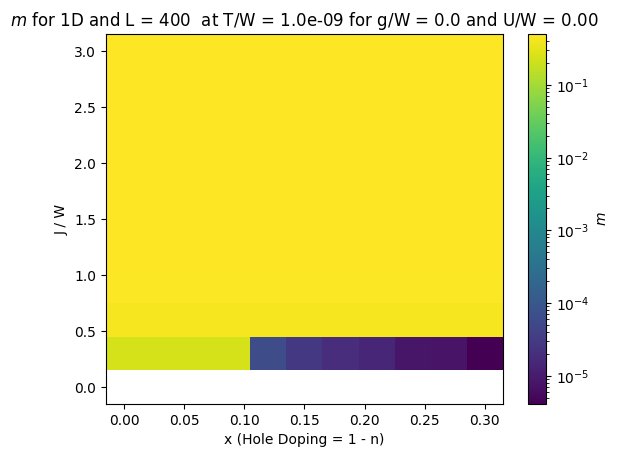

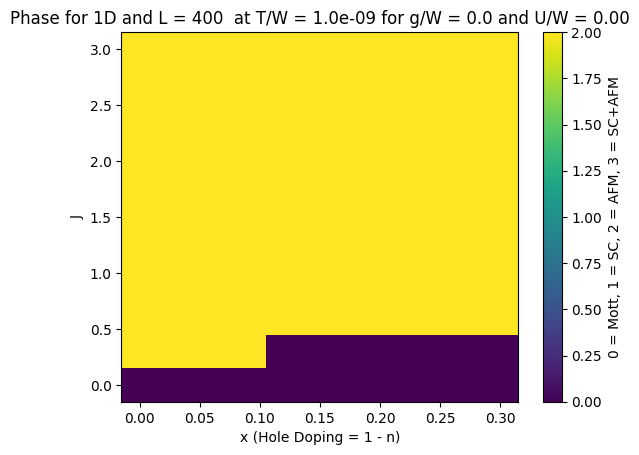

Step 1/11: computing for J / W = 0.00
Progress: 11/11
Step 2/11: computing for J / W = 0.30
Progress: 11/11
Step 3/11: computing for J / W = 0.60
Progress: 11/11
Step 4/11: computing for J / W = 0.90
Progress: 11/11
Step 5/11: computing for J / W = 1.20
Progress: 11/11
Step 6/11: computing for J / W = 1.50
Progress: 11/11
Step 7/11: computing for J / W = 1.80
Progress: 11/11
Step 8/11: computing for J / W = 2.10
Progress: 11/11
Step 9/11: computing for J / W = 2.40
Progress: 11/11
Step 10/11: computing for J / W = 2.70
Progress: 11/11
Step 11/11: computing for J / W = 3.00
Progress: 11/11


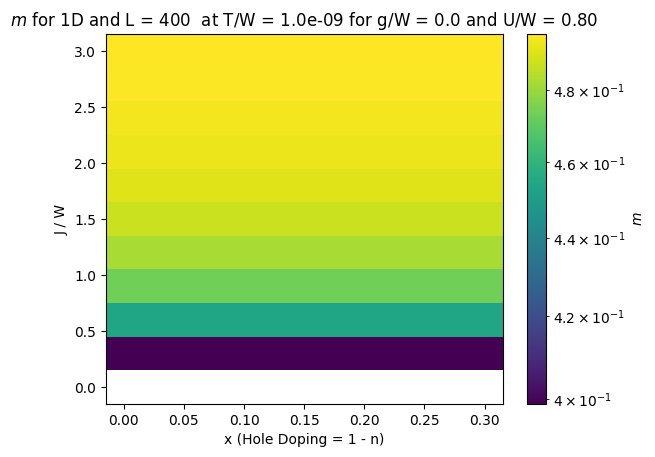

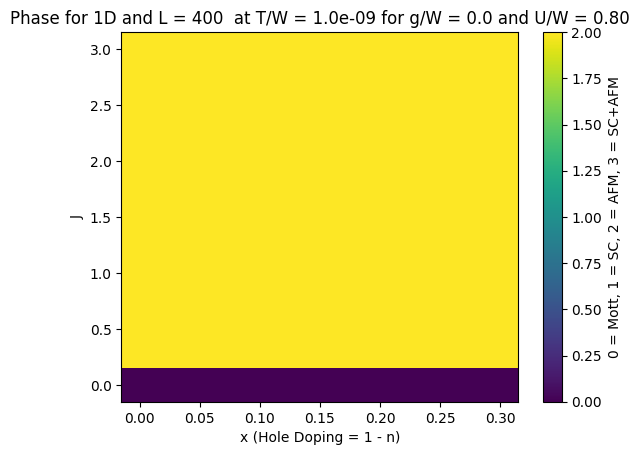

Step 1/11: computing for J / W = 0.00
Progress: 11/11
Step 2/11: computing for J / W = 0.30
Progress: 11/11
Step 3/11: computing for J / W = 0.60
Progress: 11/11
Step 4/11: computing for J / W = 0.90
Progress: 11/11
Step 5/11: computing for J / W = 1.20
Progress: 11/11
Step 6/11: computing for J / W = 1.50
Progress: 11/11
Step 7/11: computing for J / W = 1.80
Progress: 11/11
Step 8/11: computing for J / W = 2.10
Progress: 11/11
Step 9/11: computing for J / W = 2.40
Progress: 11/11
Step 10/11: computing for J / W = 2.70
Progress: 11/11
Step 11/11: computing for J / W = 3.00
Progress: 11/11


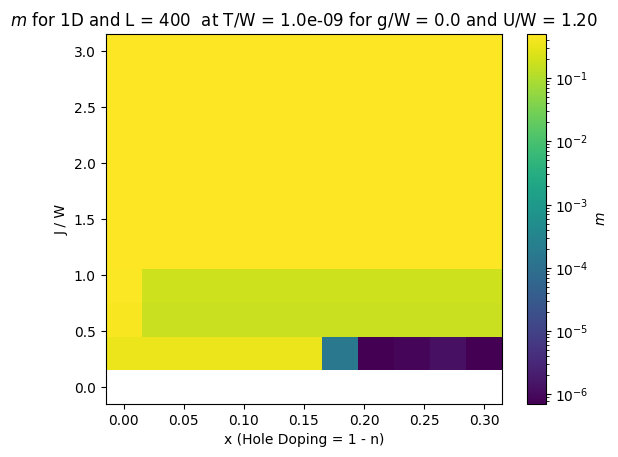

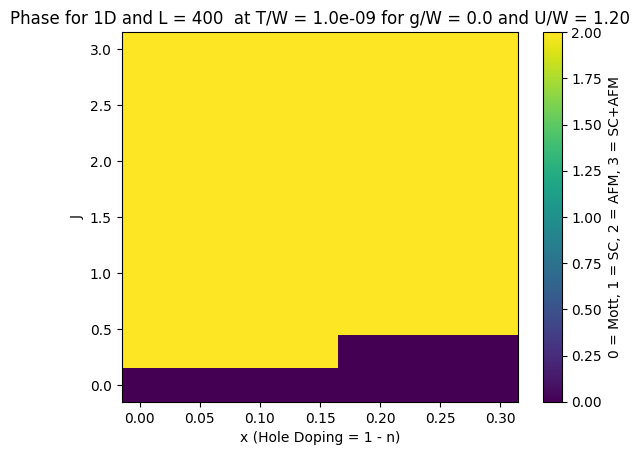

Step 1/11: computing for J / W = 0.00
Progress: 11/11
Step 2/11: computing for J / W = 0.30
Progress: 11/11
Step 3/11: computing for J / W = 0.60
Progress: 11/11
Step 4/11: computing for J / W = 0.90
Progress: 11/11
Step 5/11: computing for J / W = 1.20
Progress: 11/11
Step 6/11: computing for J / W = 1.50
Progress: 11/11
Step 7/11: computing for J / W = 1.80
Progress: 11/11
Step 8/11: computing for J / W = 2.10
Progress: 11/11
Step 9/11: computing for J / W = 2.40
Progress: 11/11
Step 10/11: computing for J / W = 2.70
Progress: 11/11
Step 11/11: computing for J / W = 3.00
Progress: 11/11


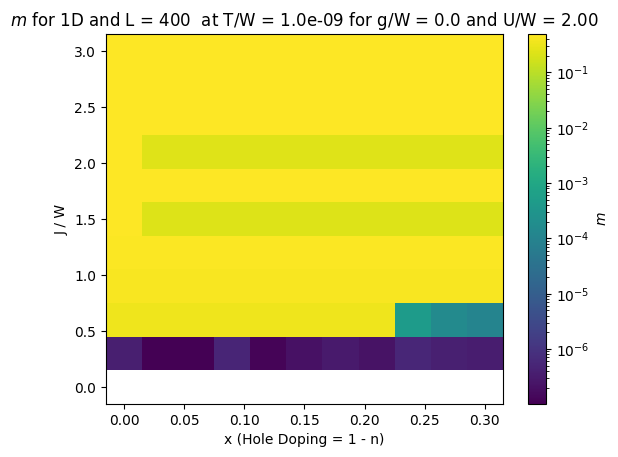

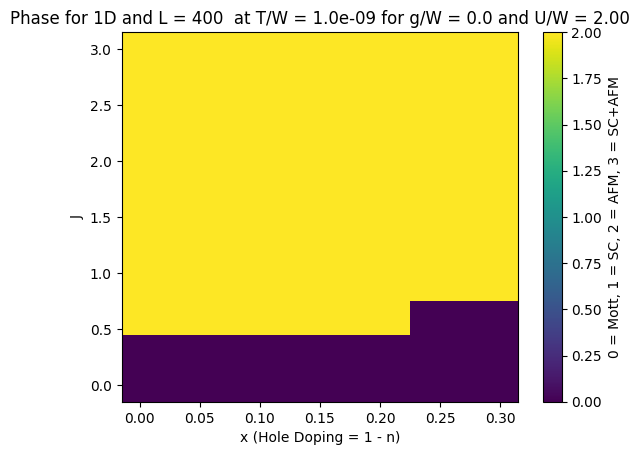

In [ ]:
# CONSTANTS
d = 1
W = 4 * d

# PARAMETERS
L = 500
g = 0 * W
T = 1e-9 * W

# Hubbard 
uu = np.array([0.0, 0.8, 1.2, 2.0]) * W

# CALCULATION PARAMETERS
# We use higher errors while computing the chemical potential mu

# Delta
delta_start = 1e-2
delta_eps_mu = 1e-3
delta_eps = 1e-4
delta_zero_mult = 1e-2

# Magnetization
m_start = 1e-2
m_eps_mu = 1e-4
m_eps = 1e-5
m_zero_mult = 1e-3


# J Sweep
J_min = 0*W
J_max = 0.15
J_ste = 13

jj = np.linspace(J_min, J_max, J_ste)


# X sweep
x_min = 0
x_max = 0.3
x_ste = 13

xx = np.linspace(x_min, x_max, x_ste)
mu_eps = 1e-3


# Calculations
for U in uu:


    # Make the mesh
    xx_mesh, jj_mesh = np.meshgrid(xx, jj)

    dd_mesh = np.zeros_like(jj_mesh)
    mm_mesh = np.zeros_like(jj_mesh)
    for ij, J in enumerate(jj):

        print(f"Step {ij + 1}/{J_ste}: computing for J / W = {J / W:.2f}")

        succ = 0
        for ix, x in enumerate(xx):

            # Target filling
            n_target = 1 - x

            # Bissect for mu
            mu_min = -W/2 - U - g - J - 0.1
            mu_max = U/2 + J + 0.1

            mu = bissect(lambda mu_test: solve(L, d, mu_test, U, g, J, T, delta_start=delta_start, delta_eps=delta_eps_mu, m_start=m_start, m_eps=m_eps_mu)[1] - n_target, mu_min, mu_max, eps = mu_eps)
            
            # Solve for converged mu
            delta, n, afm, fm, Kx = solve(L, d, mu, U, g, J, T, delta_start=delta_start, delta_eps=delta_eps, m_start=m_start, m_eps=m_eps)

            # # Solve for fixed mu
            # try:
            #     delta, n, afm, fm, Kx = solve(L, d, mu, U, g, J, T, delta_start=delta_start, delta_eps=delta_eps, m_start=m_start, m_eps=m_eps)
            #     print("\n", mu, n)
            
            # except np.linalg.LinAlgError:
            #     print(f"Error for mu = {mu} (x is ≈ {xx_mesh[ij, im - 1]})")
            #     n = 1 - xx_mesh[ij, im - 1]
            #     delta = 0
            #     afm = 0
                

            # Save
            dd_mesh[ij, ix] = delta
            mm_mesh[ij, ix] = afm

            # Show progress
            print(f"\rProgress: {ix + 1}/{x_ste}", end="")

        # Reset print
        print("")
    
    # Set zeros to a fraction of the maximum value
    delta_zero = delta_zero_mult * np.max(dd_mesh)
    m_zero = m_zero_mult * np.max(mm_mesh)

    # Make the phase diagram
    pp_mesh = np.zeros_like(jj_mesh)
    pp_mesh += 1 * (dd_mesh > delta_zero)
    pp_mesh += 2 * (mm_mesh > m_zero)
    
    # with np.printoptions(precision=3, suppress=True, threshold=100_000, linewidth=200):
    #     print(f"Fillings: {np.average(xx_mesh, axis=0)}")
    # with np.printoptions(precision=3, suppress=True, threshold=100_000, linewidth=200):
    #     print(f"With std = {np.std(xx_mesh*100, axis=0)}/100")
    
    if np.max(dd_mesh) != 0:
        plt.title(f"$\\Delta$ for {d}D and L = {L} at T/W = {T/W:.1e} for g/W = {g/W:.2f} and U/W = {U/W:.2f}")
        plt.pcolormesh(xx_mesh, jj_mesh / W, dd_mesh, cmap="viridis", norm=colors.LogNorm(vmin=np.min(dd_mesh[dd_mesh > 0]), vmax=np.max(dd_mesh)))
        plt.colorbar(label="$\\Delta$")
        plt.xlabel("x (Hole Doping = 1 - n)")
        plt.ylabel("J / W")
        plt.show()

    if np.max(mm_mesh) != 0:
        plt.title(f"$m$ for {d}D and L = {L}  at T/W = {T/W:.1e} for g/W = {g/W:.2f} and U/W = {U/W:.2f}")
        plt.pcolormesh(xx_mesh, jj_mesh / W, mm_mesh, cmap="viridis", norm=colors.LogNorm(vmin=np.min(mm_mesh[mm_mesh > 0]), vmax=np.max(mm_mesh)))
        plt.colorbar(label="$m$")
        plt.xlabel("x (Hole Doping = 1 - n)")
        plt.ylabel("J / W")
        plt.show()

    plt.title(f"Phase for {d}D and L = {L}  at T/W = {T/W:.1e} for g/W = {g/W:.2f} and U/W = {U/W:.2f}")
    plt.pcolormesh(xx_mesh, jj_mesh / W, pp_mesh, cmap="viridis")
    plt.colorbar(label="0 = Mott, 1 = SC, 2 = AFM, 3 = SC+AFM")
    plt.xlabel("x (Hole Doping = 1 - n)")
    plt.ylabel("J")
    plt.show()

## Studying Magnetic order for $g = 0$

### Comparison with Theory

tt_Tc = 200.0
Progress: 30/30

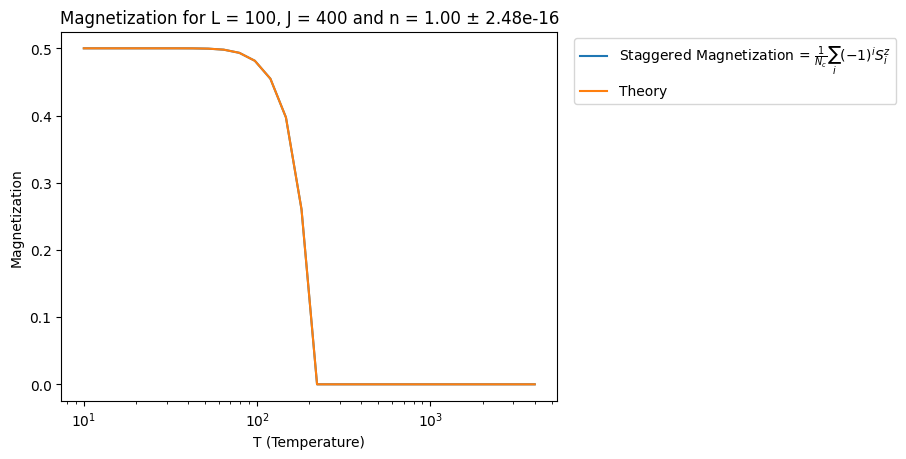

In [19]:
# DIMENSIONS
d = 1
W = 4 * d


# PHYSICAL PARAMETERS
g = 0
U = 0
J = 100*W
mu = U/2


# CALCULATION PARAMETERS
L = 100


# Temperature Sweep (around the theoretical Tc)
tt_Tc = J * 2 * (1/4)

print(f"tt_Tc = {tt_Tc}")

tt_min = tt_Tc * 20
tt_max = tt_Tc / 20
tt_ste = 30

tt = np.logspace(np.log10(tt_min), np.log10(tt_max), tt_ste)


nn = []
ff = []
aa = []
mm = []
for index, T in enumerate(tt):

    # Compute
    Delta, n, afm, fm, Kxx = solve(L, d, mu, U, g, J, T, delta_start=0, m_start=0.01, m_eps=1e-6)

    # Theory
    try:
        m = bissect(lambda m: 0.5 * np.tanh(J * (2*d) * m / (2*T)) - m, 1e-5, 0.6, eps=1e-5)
    except ValueError:
        m = 0

    print(f"\rProgress: {index + 1}/{len(tt)}", end="")

    # Save
    nn += [n]
    ff += [fm]
    aa += [afm]
    mm += [m]

plt.title(f"Magnetization for L = {L}, J = {J} and n = {np.average(nn):.2f} ± {np.std(nn):.2e}")
plt.plot(tt, aa, label="Staggered Magnetization = $\\frac{1}{N_c}\\sum_i (-1)^i S_i^z$")
plt.plot(tt, mm, label="Theory")
plt.xlabel("T (Temperature)")
plt.xscale("log")
plt.ylabel("Magnetization")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

### Low-Temperature Order

Progress: 31/31

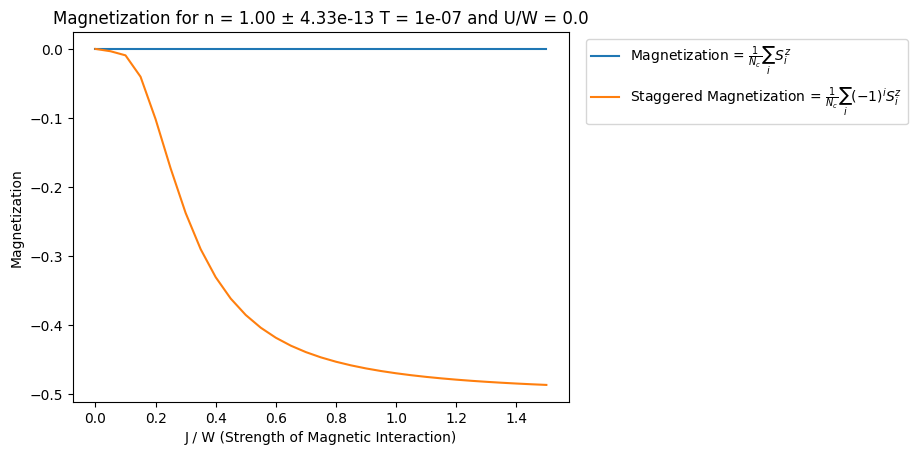

In [8]:
# CONSTANTS
d = 1
W = 4

# PHYSICAL PARAMETERS
L = 1000
g = 0
U = 0
mu = U/2
T = 1e-7

# The Hamiltonian is only AFM for J > 0
# We can get the other orientation of AFM by making m_start have the other sign
jj_min = 0 * W
jj_max = 1.5 * W
jj_steps = 31

jj = np.linspace(jj_min, jj_max, jj_steps)


nn = []
ff = []
aa = []
for index, J in enumerate(jj):

    # Set chemical potential
    mu = U/2

    # Compute
    Delta, n, afm, fm, Kxx = solve(L, d, mu, U, g, J, T, delta_start=0, m_start=0.01, m_eps=1e-6)

    print(f"\rProgress: {index + 1}/{len(jj)}", end="")

    # Save
    nn += [n]
    ff += [fm]
    aa += [-afm]

plt.title(f"Magnetization for n = {np.average(nn):.2f} ± {np.std(nn):.2e} T = {T} and U/W = {U/W:.1f}")
plt.plot(jj, aa)
plt.xlabel("J (Strength of Magnetic Interaction)")
plt.ylabel("Magnetization")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

C:\Users\guilh\AppData\Local\Temp\ipykernel_14720\3767424511.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))


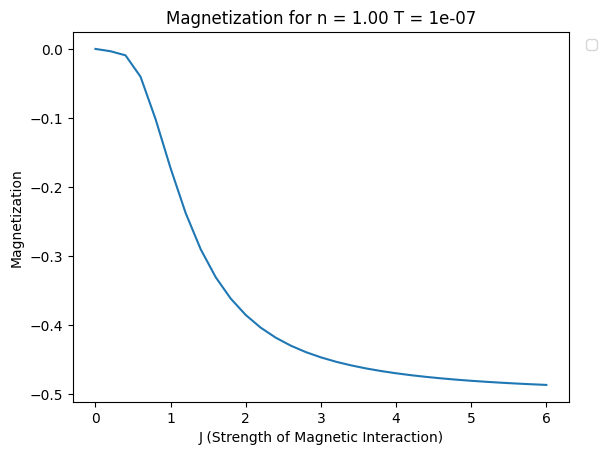

In [11]:
plt.title(f"Magnetization for n = {np.average(nn):.2f} T = {T}")
plt.plot(jj, aa)
plt.xlabel("J (Strength of Magnetic Interaction)")
plt.ylabel("Magnetization")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

### Chemical Potential

In [ ]:
# CONSTANTS
d = 1
W = 4

# PHYSICAL PARAMETERS
L = 500
g = 0
U = 0.2 * W
T = 1e-9
J = 2 * W


# Mu Sweep
mu_min = -0.5*W - g
mu_max = U/2
mu_ste = 11

mm = np.linspace(mu_min, mu_max, mu_ste)



nn = []
ff = []
aa = []
for index, mu in enumerate(mm):

    # Compute
    Delta, n, afm, fm, Kxx = solve(L, d, mu, U, g, J, T, delta_start=0, m_start=0.01, m_eps=1e-6)
    print("\n", mu, n)

    print(f"\rProgress: {index + 1}/{len(jj)}", end="")

    # Save
    nn += [n]
    ff += [fm]
    aa += [-afm]

plt.title(f"Filling for T = {T}, J/W = {J/W}, and U/W = {U/W:.1f}")
plt.plot(mm/W, nn)
plt.xlabel("$\\mu / W$ (Chemical Potential)")
plt.ylabel("Filling")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

plt.title(f"Magnetization for T = {T}, J/W = {J/W}, and U/W = {U/W:.1f}")
plt.plot(mm, ff, label="Magnetization = $\\frac{1}{N_c}\\sum_i S_i^z$")
plt.plot(mm, aa, label="Staggered Magnetization = $\\frac{1}{N_c}\\sum_i (-1)^i S_i^z$")
plt.xlabel("$\\mu / t$ (Chemical Potential)")
plt.ylabel("Magnetization")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()


 -2.0 0.0
Progress: 1/31
 -1.76 0.156
Progress: 2/31
 -1.52 0.22399999999999995
Progress: 3/31
 -1.28 0.276
Progress: 4/31
 -1.04 0.452
Progress: 5/31
 -0.8 0.5720000000000002
Progress: 6/31
 -0.56 0.668
Progress: 7/31
 -0.32000000000000006 0.7560000000000001
Progress: 8/31

KeyboardInterrupt: 

## Computing $K$ for $J = 0$

Progress: 50/50
Done U = 0.0 and g = 0.0
Progress: 50/50
Done U = 0.0 and g = 3.0
Progress: 50/50
Done U = 12.0 and g = 0.0
Progress: 50/50
Done U = 12.0 and g = 3.0


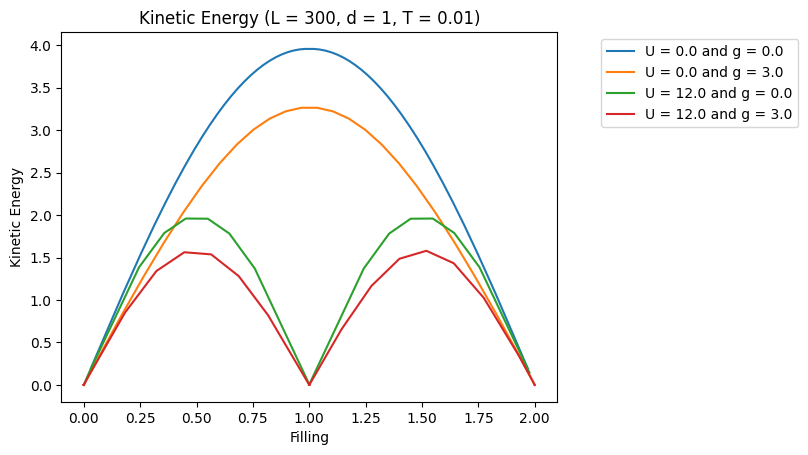

In [10]:
# CONSTANTS
d = 1
W = 4

# PARAMETERS
L = 300
J = 0
T = 0.01


# g SWEEP
gg = [0.0, 3.0]

# U SWEEP
uu = [0.0, 12.0]

# Calculations
for U in uu:
    for g in gg:

        # Range of mu to compute
        mu_min = -2*d - U - g
        mu_max = -mu_min
        mu_steps = 50

        mm = np.linspace(mu_min, mu_max, mu_steps)

        nn = []
        ss = []
        for index, mu in enumerate(mm):

            # Solve the Hamiltonian
            Delta, n, afm, fm, Kxx = solve(L, d, mu, U, g, J, T)

            # Save the filling
            nn += [n]

            # Save the superfluid stifness
            ss += [Kxx]

            # Show progress
            print(f"\rProgress: {index + 1}/{len(mm)}", end="")
        
        print("")
        print(f"Done U = {U} and g = {g}")
            
        plt.plot(nn, ss, label=f"U = {U} and g = {g}")

plt.title(f"Kinetic Energy (L = {L}, d = {d}, T = {T})")
plt.xlabel("Filling")
plt.ylabel("Kinetic Energy")
plt.legend(bbox_to_anchor=(1.5, 1.))

## Filling $n(\mu)$ for a 1D Tight-Binding Chain

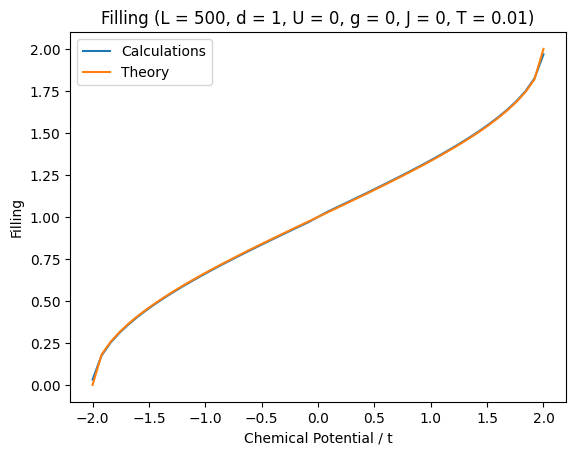

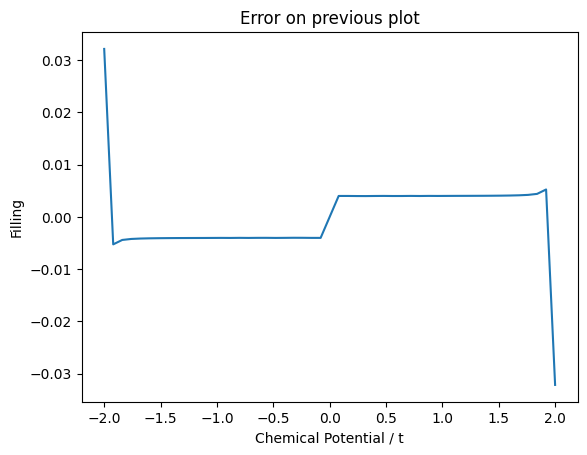

In [9]:
# PARAMETERS
L = 500
d = 1
U = 0
g = 0
J = 0
T = 0.01


# MU SWEEP
mu_start = -2*d - U
mu_end = -mu_start
mu_steps = int(L/10)


# Calculations
mm = np.linspace(mu_start, mu_end, mu_steps+1)
nn = []
for mu in mm:

    # Solve the Hamiltonian
    Delta, n, afm, fm, Kxx = solve(L, d, mu, U, g, J, T)

    # Save the filling
    nn += [n]

nn_theory = (2 / np.pi) * np.arccos(-0.5 * mm)

plt.title(f"Filling (L = {L}, d = {d}, U = {U}, g = {g}, J = {J}, T = {T})")
plt.ylabel("Filling")
plt.xlabel("Chemical Potential / t")
plt.plot(mm, nn, label="Calculations")
plt.plot(mm, nn_theory, label="Theory")
plt.legend()
plt.show()

plt.title("Error on previous plot")
plt.plot(mm, nn - nn_theory)
plt.ylabel("Filling")
plt.xlabel("Chemical Potential / t")
plt.show()